[Spreadsheet](https://docs.google.com/spreadsheets/d/1WSe-pdLR9ymZ8f2oRhvGDu90T6VJ3k4NNZf3sM7Fx_k/edit?usp=sharing)

https://www.learnpytorch.io/

# PyTorch Custom Datasets

PyTorch includes many existing functions to load in various custom datasets in the TorchVision, TorchText, TorchAudio and TorchRec domain libraries.

But sometimes these existing functions may not be enough.

In that case, we can always subclass torch.utils.data.Dataset and customize it to our liking.

| **Topic** | **Contents** |
|-----------|--------------|
| **0. Importing libraries and setting up device-agnostic code** | Let's get PyTorch loaded and then follow best practice to setup our code to be device-agnostic. |
| **1. Get data** | Download sample of data and whole data |
| **2. Loading data and Transforming data** | Often, the data you get won't be 100% ready to use with a machine learning model, here we'll look at some steps we can take to *transform* our images so they're ready to be used with a model. |
| **3. Become one with the data (data preparation)** | Explore and visualize data |
| **4. Prepare Dataloader** | Turn data into batches. |
| **5. Other forms of transforms (data augmentation)** | Data augmentation is a common technique for expanding the diversity of your training data. Here we'll explore some of `torchvision`'s in-built data augmentation functions. |
| **6. Model 0: TinyVGG** | build a model capable of fitting it. We'll also create some training and testing functions for training and evaluating our model. |
| **7. Exploring loss curves** | Loss curves are a great way to see how your model is training/improving over time. They're also a good way to see if your model is **underfitting** or **overfitting**. |
| **9. Model 1: TinyVGG++** | Make the model complexer to prevent underfitting. |
| **10. Compare model results [Spreadsheet](https://docs.google.com/spreadsheets/d/1WSe-pdLR9ymZ8f2oRhvGDu90T6VJ3k4NNZf3sM7Fx_k/edit?usp=sharing)** | Let's compare our different models' loss and see which performed better and discuss some options for improving performance. |
| **11. Improve Model to beat 80% top-1** | Try to build that model [here](https://colab.research.google.com/drive/1rP3zPKrlYdyVgj-LEIYXDL-fB6B4aG7h?usp=sharing) |
| **12. Save and Load the Model** | Save and Load the best model |
**13. Making a prediction on a custom image** | Use our trained model to predict on an image *outside* of our existing dataset. |


https://www.learnpytorch.io/04_pytorch_custom_datasets/

## **0. Imports**

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2 as cv
from google.colab.patches import cv2_imshow as imshow

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import datasets, transforms
import torchvision.models as models

torch.__version__, torchvision.__version__

('2.8.0+cu126', '0.23.0+cu126')

## **1. Constants** *

In [3]:
!nvidia-smi

Wed Aug 20 16:29:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
DEVICE = "mps" if torch.mps.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else DEVICE
DEVICE

'cuda'

In [5]:
RANDOM_SEED = 42

LOAD_SAMPLE = False # ~ 1%

FRACTION = False # Only on whole data(LOAD_SAMPLE=False)
FRACTION_SIZE = 0.2 # 20% of foods

# DATA_LINK, WGET = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz", True # 100%
DATA_LINK, WGET, FRACTION = "https://drive.google.com/file/d/1Kd3cq5St2gcRqZ4xRu-uT90wYTpii5in/view?usp=sharing", False, False # 20%

BATCH_SIZE = 1 if LOAD_SAMPLE else 32

## **2. Download Data** *

Start small and upgrade if it necessary


https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/

In [6]:
import requests
import zipfile
from pathlib import Path
import tarfile

### 2.0. Sample

In [7]:
if LOAD_SAMPLE:
  # Setup path to data folder
  data_path = Path("data/")
  image_path = data_path / "pizza_steak_sushi"

  # If the image folder doesn't exist, download it and prepare it...
  if image_path.is_dir():
      print(f"{image_path} directory exists.")
  else:
      print(f"Did not find {image_path} directory, creating one...")
      image_path.mkdir(parents=True, exist_ok=True)

      # Download pizza, steak, sushi data
      with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
          request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
          print("Downloading pizza, steak, sushi data...")
          f.write(request.content)

      # Unzip pizza, steak, sushi data
      with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
          print("Unzipping pizza, steak, sushi data...")
          zip_ref.extractall(image_path)

### 2.1. Whole Data

In [8]:
import gdown

if not LOAD_SAMPLE:
  if WGET:
    # 100%
    !wget -O food_101.tar.gz {DATA_LINK}
  else:
    # 20%
    file_id = DATA_LINK.split("/")[-2]
    output_path = 'food_101.tar.gz'

    gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Kd3cq5St2gcRqZ4xRu-uT90wYTpii5in
From (redirected): https://drive.google.com/uc?id=1Kd3cq5St2gcRqZ4xRu-uT90wYTpii5in&confirm=t&uuid=a1139e28-b235-49de-93d3-9cc5859ef1c8
To: /content/food_101.tar.gz
100%|██████████| 999M/999M [00:15<00:00, 65.7MB/s]


In [9]:
if not LOAD_SAMPLE:
  # Setup path to data folder
  data_path = Path("data_full/")
  image_path_f = data_path / "food_101"

  # If the image folder doesn't exist, download it and prepare it...
  if image_path_f.is_dir():
      print(f"{image_path_f} directory exists.")
  else:
      print(f"Did not find {image_path_f} directory, creating one...")
      image_path_f.mkdir(parents=True, exist_ok=True)


      # Define the path to your .tar.gz file
      file_name = 'food_101.tar.gz'

      # Define the destination directory where you want to extract the contents
      destination_folder = image_path_f

      try:
          # Open the tar.gz file in read mode ('r:gz')
          # The 'with' statement ensures the file is properly closed even if errors occur
          with tarfile.open(file_name, 'r:gz') as tar:
              # Extract all contents to the specified destination folder
              tar.extractall(path=destination_folder)
          print(f"Successfully extracted '{file_name}' to '{destination_folder}'.")
      except tarfile.ReadError:
          print(f"Error: Could not open or read '{file_name}'. It might be corrupted or not a valid tar.gz file.")
      except FileNotFoundError:
          print(f"Error: The file '{file_name}' was not found.")
      except Exception as e:
          print(f"An unexpected error occurred: {e}")

/tmp/ipython-input-4025990578.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination_folder)


Did not find data_full/food_101 directory, creating one...
Successfully extracted 'food_101.tar.gz' to 'data_full/food_101'.


### 2.2. Define Paths

In [10]:
if LOAD_SAMPLE:
  # Setup train and testing paths
  train_dir = os.path.join(image_path, "train")
  test_dir = os.path.join(image_path, "test")

  print((train_dir, test_dir))
else:
  image_path = Path(os.path.join(image_path_f, "food-101", "images"))

  print(image_path)

data_full/food_101/food-101/images


In [11]:
if not LOAD_SAMPLE and FRACTION:
  random.seed(RANDOM_SEED)
  food_dirs = os.listdir(image_path)
  selected_foods = random.sample(food_dirs, k=int(len(food_dirs) * FRACTION_SIZE))

  for selected_food in selected_foods:
    !cp -r {os.path.join(image_path, selected_food)} "fraction_of_data"

  image_path = Path("fraction_of_data")

In [12]:
image_path

PosixPath('data_full/food_101/food-101/images')

### 2.3. Upload fraction of data on google colab for easy reuse

In [13]:
# from google.colab import drive
# drive.mount('/content/drive')

In [14]:
# # !mkdir "food-101/"
# # !mkdir "food-101/images"

# random.seed(RANDOM_SEED)
# food_dirs = os.listdir(image_path)
# selected_foods = random.sample(food_dirs, k=int(len(food_dirs) * FRACTION_SIZE))

# for selected_food in selected_foods:
#   !cp -r {os.path.join(image_path, selected_food)} "food-101/images"

In [15]:
# # Open the tar file in write with gzip compression mode
# with tarfile.open("food_101.tar.gz", "w:gz") as tar:
#     # Add the folder to the archive
#     tar.add("food-101", arcname=os.path.basename("food-101"))

In [16]:
# !cp -r "food_101.tar.gz" "/content/drive/MyDrive/Datasets/Food_101_20p"

### 2.4. Walkthrough image_path

In [17]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [18]:
walk_through_dir(image_path)

There are 20 directories and 0 images in 'data_full/food_101/food-101/images'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/seaweed_salad'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/cup_cakes'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/steak'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/red_velvet_cake'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/baby_back_ribs'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/pancakes'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/pho'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/chicken_quesadilla'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/caesar_salad'.
There are 0 directories and 1000 images in 'data_full/food_101/food-101/images/cheesec

## **3. Load Data** *

### 3.0. Transforms

In [26]:
### Basic
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

### 3.1. Option 1: Loading Image Data Using ImageFolder

Standard format

Test Folder -> Folder of each class

Train Folder -> Folder of each class

In [27]:
if LOAD_SAMPLE:
  train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
  test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

**Stratified Split with scikit-learn**

This guarantees each class is split proportionally across train, val, and test

In [28]:
# TODO: Augmentations only on training, but just resizing/tensor conversion for val/test)
# Hint: Load dataset twice
if not LOAD_SAMPLE:
  # load datasets with different transforms
  dataset_train = datasets.ImageFolder(image_path, transform=train_transform)
  dataset_test  = datasets.ImageFolder(image_path, transform=test_transform)
  targets = dataset_train.targets # class indices
  class_names = dataset_train.classes

  # stratified split into train and test
  targets = dataset_train.targets
  train_idx, test_idx = train_test_split(
      range(len(dataset_train)),
      test_size=0.2,   # 20% for test
      stratify=targets,
      random_state=RANDOM_SEED
  )

  # subsets with the correct transforms
  train_dataset = Subset(dataset_train, train_idx)
  test_dataset  = Subset(dataset_test, test_idx)

In [29]:
len(train_dataset), len(test_dataset)

(16000, 4000)

In [73]:
if LOAD_SAMPLE:
  class_names = train_dataset.classes
print(class_names)

['baby_back_ribs', 'baklava', 'bibimbap', 'bruschetta', 'caesar_salad', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'crab_cakes', 'cup_cakes', 'filet_mignon', 'fried_calamari', 'pancakes', 'pho', 'red_velvet_cake', 'samosa', 'seaweed_salad', 'spring_rolls', 'steak', 'waffles']


### 3.2. Option 2: Loading Image Data Using Custom Dataset

<div class="md-typeset__table"><table>
<thead>
<tr>
<th>Pros of creating a custom <code>Dataset</code></th>
<th>Cons of creating a custom <code>Dataset</code></th>
</tr>
</thead>
<tbody>
<tr>
<td>Can create a <code>Dataset</code> out of almost anything.</td>
<td>Even though you <em>could</em> create a <code>Dataset</code> out of almost anything, it doesn't mean it will work.</td>
</tr>
<tr>
<td>Not limited to PyTorch pre-built <code>Dataset</code> functions.</td>
<td>Using a custom <code>Dataset</code> often results in writing more code, which could be prone to errors or performance issues.</td>
</tr>
</tbody>
</table></div>

In [31]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

#### 3.2.0. helper function to get class names

In [32]:
def find_classes(dir: str) -> Tuple[List[str], Dict[str, int]]:
  """
  Finds the class folder names in a target directory.

  Assumes target directory is in standard image classification format.
  """
  class_names = sorted([entry.name for entry in list(os.scandir(dir)) if entry.is_dir()])

  if not class_names:
    raise FileNotFoundError(f"Couldn't find any classes in {dir}.")

  class_names_idx = {cname:idx for idx, cname in enumerate(class_names)}

  return class_names, class_names_idx

In [33]:
if LOAD_SAMPLE:
  print(find_classes(train_dir))

#### 3.2.1. Create a custom Dataset to replicate ImageFolder

1. Subclass `torch.utils.data.Dataset`.

2. Initialize our subclass with a `targ_dir` parameter (the target data directory) and `transform` parameter (so we have the option to transform our data if needed).

3. Create several attributes for `paths` (the paths of our target images), `transform` (the transforms we might like to use, this can be `None`), `classes` and `class_to_idx` (from our `find_classes()` function).

4. Create a function to load images from file and return them, this could be 5.using `PIL` or `torchvision.io` (for input/output of vision data).

5. Overwrite the `__len__` method of `torch.utils.data.Dataset` to return the number of samples in the `Dataset`, this is recommended but not required. This is so you can call `len(Dataset)`.

6. Overwrite the `__getitem__` method of `torch.utils.data.Dataset` to return a single sample from the Dataset, this is required.


In [34]:
# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2
  def __init__(self, targ_dir: str, transform: transforms=None) -> None:
    super().__init__()
    # 3
    # Get all image paths
    self.paths = list(Path(targ_dir).glob("*/*.jpg"))

    self.transform = transform

    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4 Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    image_path = self.paths[index]
    image = Image.open(image_path).convert("RGB")
    return image

  # 5 Overwrite the __len__
  def __len__(self) -> int:
    return len(self.paths)

  # 6 Overwrite the __getitem__
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    image = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      image = self.transform(image)

    return image, class_idx

#### 3.2.2 Load Data with Custom DataLoader

In [35]:
if LOAD_SAMPLE:
  train_dataset = ImageFolderCustom(train_dir, train_transform)
  test_dataset = ImageFolderCustom(test_dir, test_transform)

In [36]:
if LOAD_SAMPLE:
  print(len(train_dataset))
  print(train_dataset.classes)

#### 3.2.3 Extra Exercise (Function to **visualize** data that loaded with **ImageFolderCustom**)

In [37]:
def display_random_imgs(dataset: torch.utils.data.Dataset,
                        seed: int=None,
                        sample_size: int = 9,
                        num_of_cols: int = 3,
                        display_shape: bool=True):
  ## Apply random seed
  if seed:
    random.seed(seed)
    np.random.seed(seed)

  ## Select samples randomly
  idxs = np.random.randint(low=0, high=len(dataset), size=(sample_size, ))

  cols = num_of_cols
  rows = (sample_size // cols) + 1 if sample_size % 3 != 0 else sample_size // cols

  plt.figure(figsize=(3 * cols, 3 * rows))

  for i, image_idx in enumerate(idxs):
    img = dataset[image_idx][0].cpu().numpy()
    label = dataset[image_idx][1]
    class_name = dataset.classes[label]

    plt.subplot(rows, cols, i + 1)

    img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)
    if display_shape:
      class_name += " " + str(img.shape)
    plt.title(class_name, fontsize=10)

    plt.axis(False)

In [38]:
if LOAD_SAMPLE:
    display_random_imgs(train_dataset,
                        seed = RANDOM_SEED,
                        sample_size=19,
                        num_of_cols=5,
                        display_shape=True)

## **4. Visualize Data**

### 4.0. Original Size

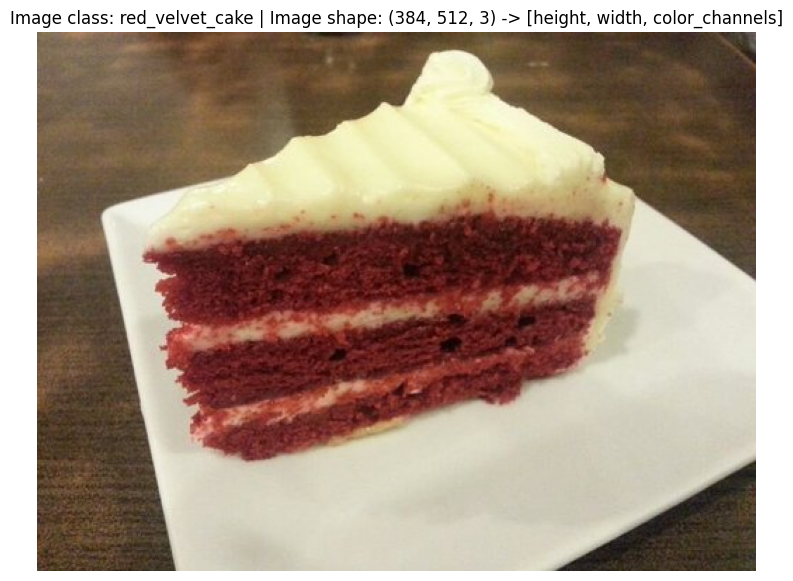

In [ ]:
from PIL import Image

# Set seed
random.seed(RANDOM_SEED) # <- try changing this and see what happens

# 1. Get all image paths (* means "any combination")
if LOAD_SAMPLE:
  image_path_list = list(image_path.glob("*/*/*.jpg"))
else:
  image_path_list = list(image_path.glob("*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

### 4.1. Transformed

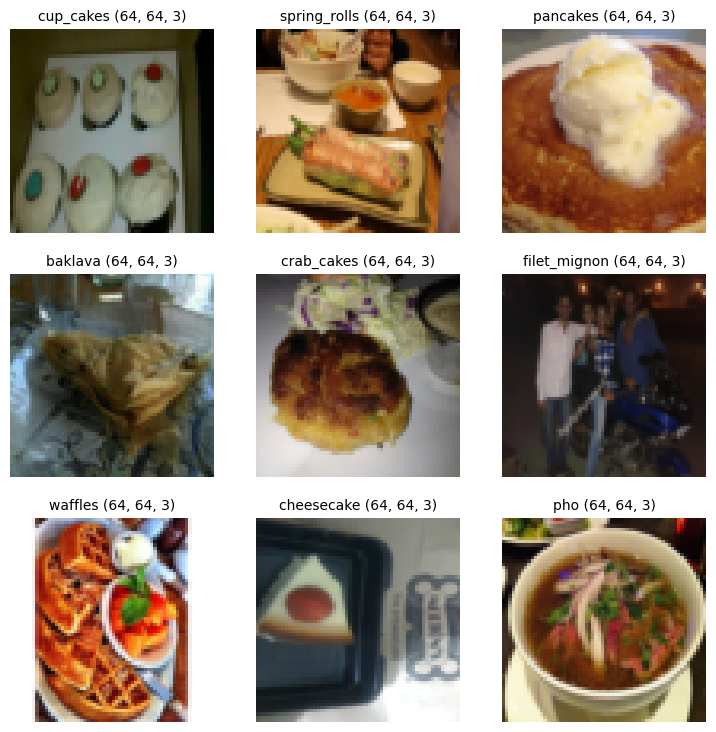

In [ ]:
# Plot random samples

# random.seed(RANDOM_SEED)
# np.random.seed(RANDOM_SEED)

NUM_SAMPLES = 9
indexes = np.random.randint(low=0, high=len(train_dataset), size=(NUM_SAMPLES, ))

ncols = 3
nrows = (NUM_SAMPLES // ncols) + 1 if NUM_SAMPLES % 3 != 0 else NUM_SAMPLES // ncols

plt.figure(figsize=(9, 3 * nrows))

for i, idx in enumerate(indexes):
  sample = train_dataset[idx][0].cpu().numpy()
  label_idx = train_dataset[idx][1]

  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the image
  sample = np.transpose(sample, (1, 2, 0)) # H, W, C
  plt.imshow(sample)

  # Get the label
  label = f"{class_names[label_idx]} {str(sample.shape)}"

  # Plot title
  plt.title(label, fontsize=10)

  plt.axis(False);

### 4.2. Transformed vs Orig

Generally, the larger the shape of the image, the more information a model can recover.

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=None):
    """
    Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    if seed:
      random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

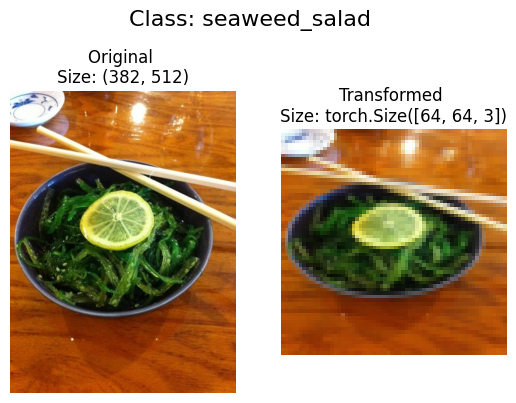

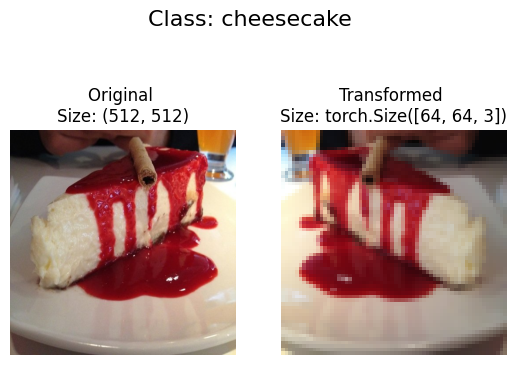

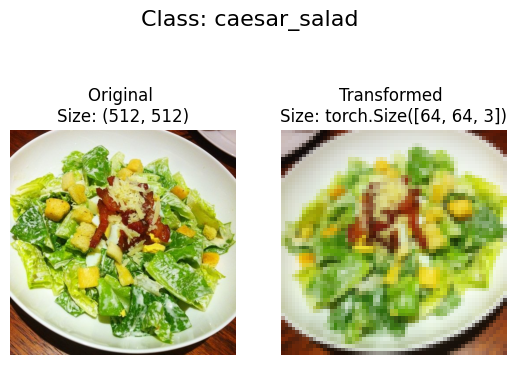

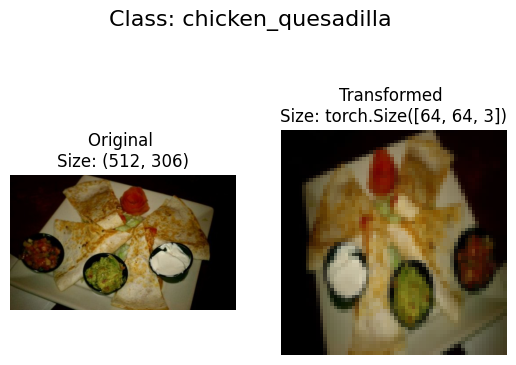

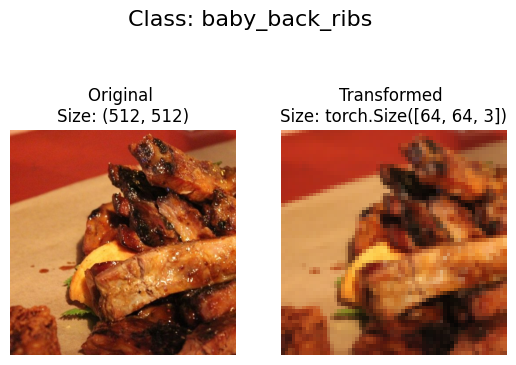

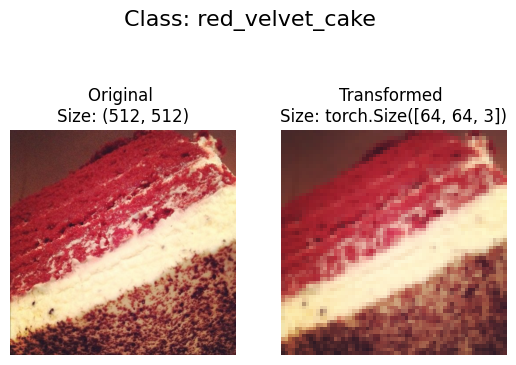

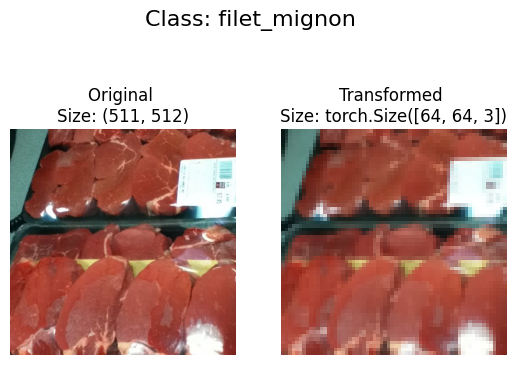

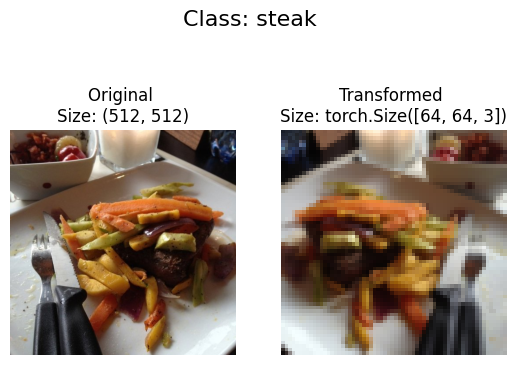

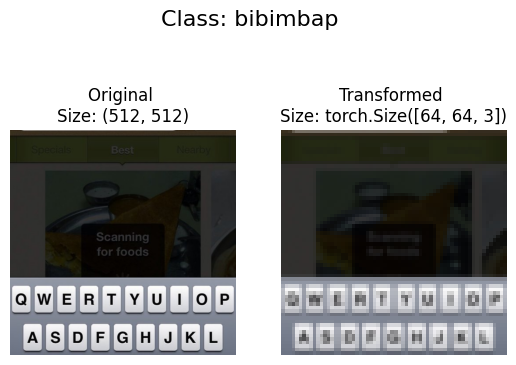

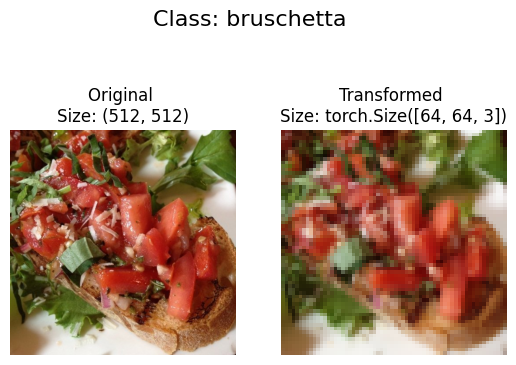

In [ ]:
plot_transformed_images(image_path_list,
                        transform=train_transform,
                        n=10,
                        # seed=RANDOM_SEED
                        )

## **5. Prepare DataLoader** *

In [ ]:
os.cpu_count()

2

In [ ]:
# # Make train_dataloader Reproducible
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())

test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count())

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


In [ ]:
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")

Length of train dataloader: 500 batches of 32 (drop last batch is False)
Length of test dataloader: 125 batches of 32 (drop last batch is False)


## **6. Other Forms of Transforms (Data Augmentation)**

**Data augmentation** is the process of altering your data in such a way that you artificially increase the diversity of your training set.

Training a model on this artificially altered dataset hopefully results in a model that is capable of better generalization (the patterns it learns are more robust to future unseen examples).

In [ ]:
# TrivialAugmentWide
train_aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
])

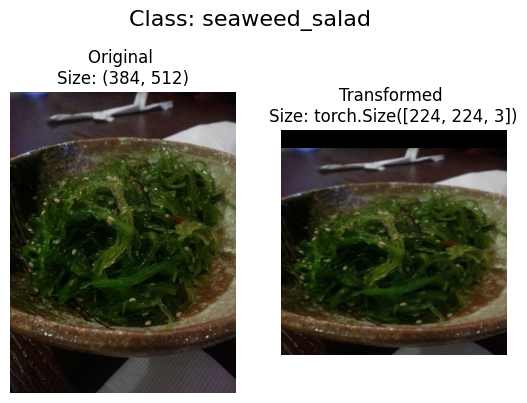

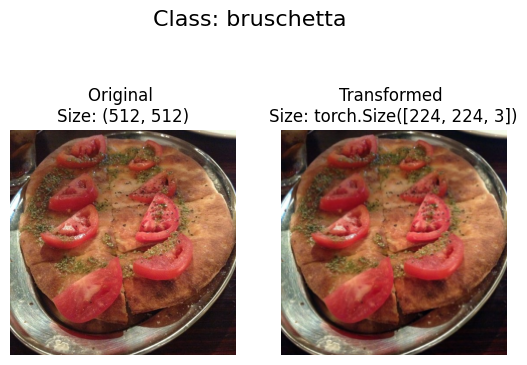

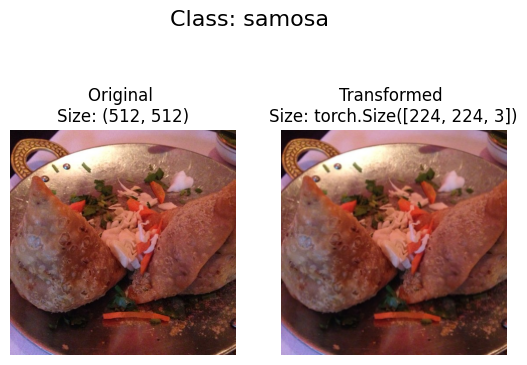

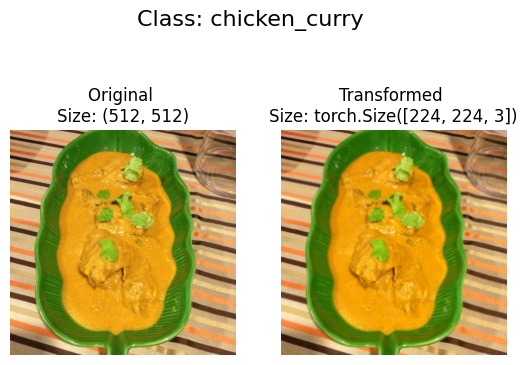

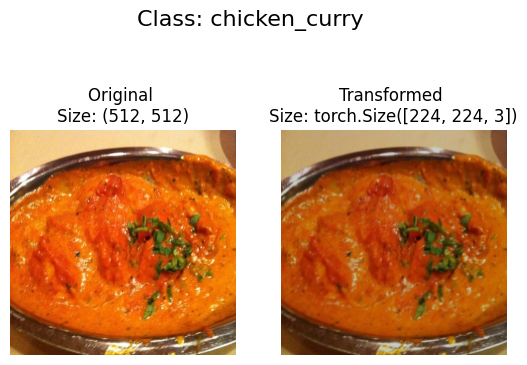

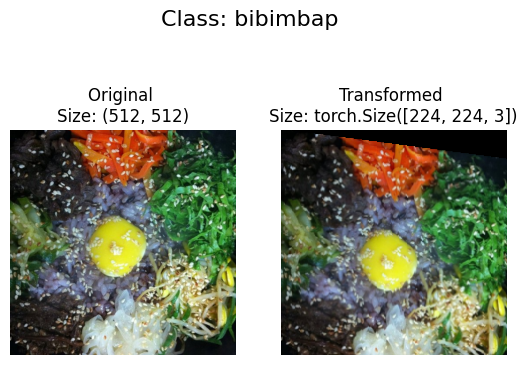

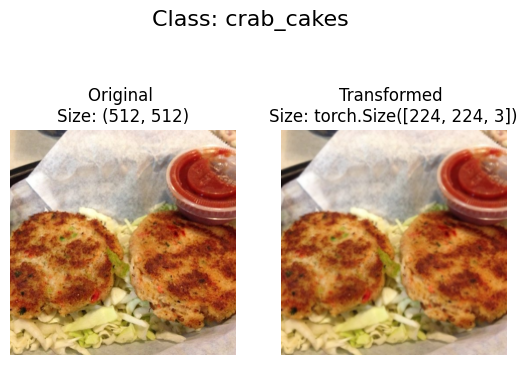

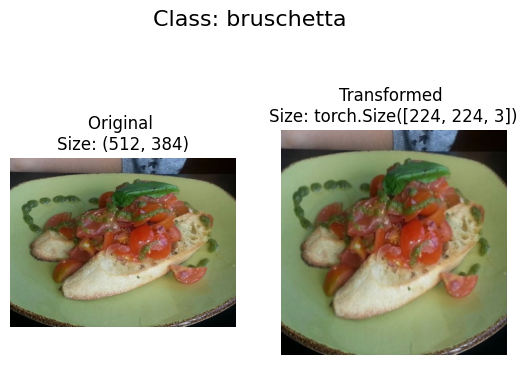

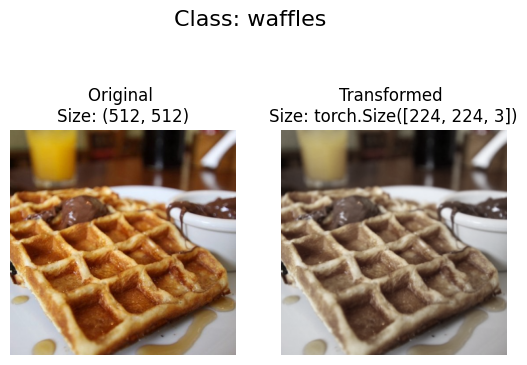

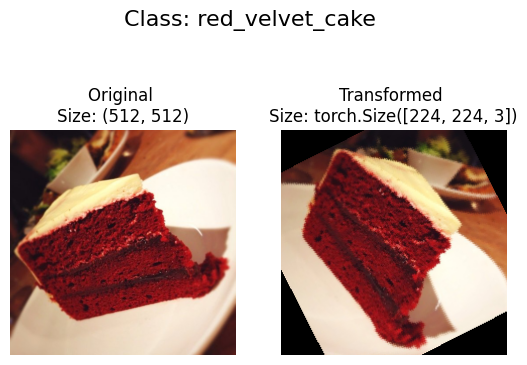

In [ ]:
if LOAD_SAMPLE:
  image_path_list = list(image_path.glob("*/*/*.jpg"))
else:
  image_path_list = list(image_path.glob("*/*.jpg"))

plot_transformed_images(image_paths=image_path_list,
                        transform=train_aug_transform,
                        n=10)

## **7. Train, Test and Eval Functions** *

### 7.0. Train

Resetting the random seed inside every epoch

* This is not good during training — it makes your data shuffling identical each epoch, which destroys the benefit of stochasticity and acts like you’re training on the same exact sequence over and over.

* That will accelerate overfitting because the model sees the exact same order and augmentations every epoch

In [19]:
def train_step(model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu"
               ):
  # model.to(device)
  model.train()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  for batch, (data, target) in enumerate(dataloader):
    data, target = data.to(device), target.to(device)

    # Forward pass
    y_logits = model(data)

    # Calculate the Loss
    loss = loss_fn(y_logits, target)
    total_loss += (loss.item() * target.size(0))

    # Count correct
    total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
    total_samples += target.size(0)

    # Zero Grad
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Apply Grad
    optimizer.step()

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Train loss: {avg_loss:.5f} | Train accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

### 7.1. Test

In [20]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: torch.device = "cpu"
              ):

  # model.to(device)
  model.eval()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  with torch.inference_mode():
    for batch, (data, target) in enumerate(dataloader):
      data, target = data.to(device), target.to(device)

      # Forward pass
      y_logits = model(data)

      # Calculate the Loss
      loss = loss_fn(y_logits, target)
      total_loss += (loss.item() * target.size(0))

      # Count correct
      total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
      total_samples += target.size(0)

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Test loss: {avg_loss:.5f} | Test accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

### 7.2. Eval

In [21]:
def eval_model(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu") -> tuple[np.ndarray, torch.Tensor, torch.Tensor]:
    """
    Return probability, prediction, and target of all samples as 1D tensors.
    """
    model.to(device)
    model.eval()

    y_probs = []
    y_preds = []
    targets = []

    with torch.inference_mode():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            # Forward pass
            y_logits = model(data)

            # Softmax probabilities and predictions
            probs = torch.softmax(y_logits, dim=1).max(dim=1).values
            preds = torch.argmax(y_logits, dim=1)

            y_probs.append(probs)
            y_preds.append(preds)
            targets.append(target)

    # Convert to proper types
    y_prob_np = torch.cat(y_probs).cpu().numpy()
    y_pred_tensor = torch.cat(y_preds).cpu()
    target_tensor = torch.cat(targets).cpu()

    return y_prob_np, y_pred_tensor, target_tensor

## **8. Model 0**

Baseline Model (TinyVGG)

### 8.0. Build the Model

In [ ]:
class FoodModelV0(nn.Module):
  def __init__(self,
               in_channels: int,
               num_classes: int,
               hidden_units: int=10
               ):

    super().__init__()

    self.in_channels = in_channels
    self.num_classes = num_classes
    self.hidden_units = hidden_units

    self.conv_block_0 = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=hidden_units, kernel_size=3, padding=0),
        nn.ReLU(True),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=0),
        nn.ReLU(True),
        nn.MaxPool2d(2),
    )


    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=0),
        nn.ReLU(True),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=0),
        nn.ReLU(True),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13, out_features=num_classes)
    )


  def forward(self, x):
    # out = self.conv_block_0(x)
    # # print(out.shape)
    # out = self.conv_block_1(out)
    # # print(out.shape)
    # out = self.classifier(out)
    # return out

    # leverage the benefits of operator fusion
    return self.classifier(self.conv_block_1(self.conv_block_0(x)))

Note: One of the ways to speed up deep learning models computing on a GPU is to leverage operator fusion.

This means in the forward() method in our model above, instead of calling a layer block and reassigning x every time, we call each block in succession (see the final line of the forward() method in the model above for an example).

This saves the time spent reassigning x (memory heavy) and focuses on only computing on x.

See [Making Deep Learning Go Brrrr From First Principles](https://horace.io/brrr_intro.html) by Horace He for more ways on how to speed up machine learning models.


### 8.1. Train the Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

model_0 = FoodModelV0(in_channels=3, num_classes=len(class_names), hidden_units=10).to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

In [ ]:
epochs = 5
logs = []

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_loss, _ = train_step(model=model_0,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            dataloader=train_dataloader,
                            device=DEVICE)

  test_loss, _ = test_step(model=model_0,
                          loss_fn=loss_fn,
                          dataloader=test_dataloader,
                          device=DEVICE)

  logs.append([epoch, train_loss, test_loss])
  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 1.10676 | Train accuracy: 36.44%
Test loss: 1.09900 | Test accuracy: 25.33%
Epoch time: 1.58s

epoch: 1

--------
Train loss: 1.03181 | Train accuracy: 50.67%
Test loss: 1.15146 | Test accuracy: 46.67%
Epoch time: 1.62s

epoch: 2

--------
Train loss: 0.95747 | Train accuracy: 53.33%
Test loss: 0.98008 | Test accuracy: 41.33%
Epoch time: 1.65s

epoch: 3

--------
Train loss: 0.93686 | Train accuracy: 60.89%
Test loss: 0.98677 | Test accuracy: 53.33%
Epoch time: 1.58s

epoch: 4

--------
Train loss: 0.88594 | Train accuracy: 59.56%
Test loss: 0.97131 | Test accuracy: 45.33%
Epoch time: 2.56s



### 8.2. Torch Info

In [ ]:
%%capture
!pip install torchinfo

In [ ]:
from torchinfo import summary

model_0_temp = FoodModelV0(in_channels=3, num_classes=3, hidden_units=10)

summary(model_0_temp, input_size=(BATCH_SIZE, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
FoodModelV0                              [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

### 8.3. Loss Curve

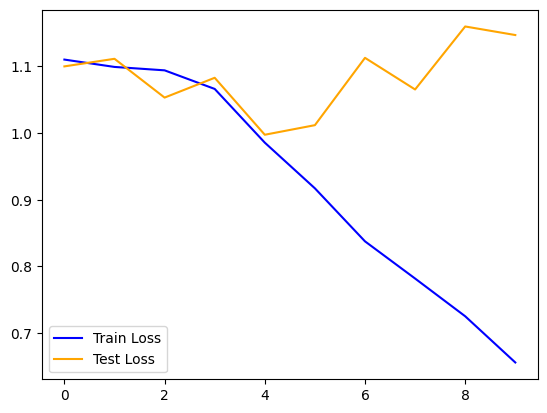

In [ ]:
logs_array = np.array(logs)

plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss", c="b")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test Loss", c="orange")

plt.legend()
plt.show()

### 8.4. Evaluate the Model

In [ ]:
probs, preds, targets = eval_model(model=model_0, dataloader=test_dataloader, device=DEVICE)

In [ ]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))

              precision    recall  f1-score   support

           0       0.36      0.48      0.41        25
           1       0.54      0.37      0.44        19
           2       0.38      0.35      0.37        31

    accuracy                           0.40        75
   macro avg       0.43      0.40      0.41        75
weighted avg       0.41      0.40      0.40        75



## **9. Model 1**

TinyVGG++

### 9.0. Build the Model

In [ ]:
class FoodModelV1(nn.Module):
    def __init__(self,
                 in_channels: int,
                 num_classes: int,
                 hidden_units: int=64):
        super().__init__()

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.hidden_units = hidden_units

        self.conv_block_0 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_units, 3, padding=0),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=0),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)  # conv block dropout
        )
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=0),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_units*2, hidden_units*2, 3, padding=0),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 2 * 13 * 13, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x = self.conv_bloc_0(x)
        # x = self.conv_block_1(x)
        # # print(x.shape) # torch.Size([1, 20, 13, 13])
        # x = self.classifier(x)
        # return x

        return self.classifier(self.conv_block_1(self.conv_block_0(x)))

### 9.1. Train the Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

model_1 = FoodModelV1(in_channels=3, num_classes=len(class_names), hidden_units=128).to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [ ]:
epochs = 10
logs = []

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_loss, _ = train_step(model=model_1,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            dataloader=train_dataloader,
                            device=DEVICE)


  test_loss, _ = test_step(model=model_1,
                          loss_fn=loss_fn,
                          dataloader=test_dataloader,
                          device=DEVICE)

  logs.append([epoch, train_loss, test_loss])
  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

### 9.2. Loss Curve

In [ ]:
for i in range(len(logs)):
  logs[i][0] = i

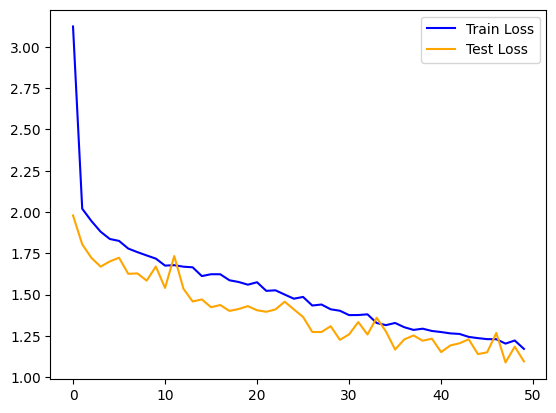

In [ ]:
logs_array = np.array(logs)

plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss", c="b")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Test Loss", c="orange")

plt.legend()
plt.show()

Is our model underfitting or overfitting? **underfitting**

### 9.3. Evaluate the Model

In [ ]:
probs, preds, targets = eval_model(model=model_1, dataloader=test_dataloader, device=DEVICE)

In [ ]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       200
           1       0.50      0.67      0.57       200
           2       0.82      0.52      0.64       200
           3       0.98      0.90      0.94       200
           4       0.35      0.51      0.41       200
           5       0.80      0.82      0.81       200
           6       0.53      0.60      0.56       200
           7       0.73      0.68      0.70       200
           8       0.26      0.15      0.19       200

    accuracy                           0.63      1800
   macro avg       0.64      0.63      0.63      1800
weighted avg       0.64      0.63      0.63      1800



## **10. Underfitting and Overfitting**

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-loss-curves-overfitting-underfitting-ideal.jpg" width=620>

### 10.0. How to deal with overfitting

Since the main problem with overfitting is that your model is fitting the training data too well, you'll want to use techniques to "reign it in".

A common technique of preventing overfitting is known as [regularization](https://ml-cheatsheet.readthedocs.io/en/latest/regularization.html).

<div class="md-typeset__table"><table>
<thead>
<tr>
<th><strong>Method to prevent overfitting</strong></th>
<th><strong>What is it?</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Get more data</strong></td>
<td>Having more data gives the model more opportunities to learn patterns, patterns which may be more generalizable to new examples.</td>
</tr>
<tr>
<td><strong>Simplify your model</strong></td>
<td>If the current model is already overfitting the training data, it may be too complicated of a model. This means it's learning the patterns of the data too well and isn't able to generalize well to unseen data. One way to simplify a model is to reduce the number of layers it uses or to reduce the number of hidden units in each layer.</td>
</tr>
<tr>
<td><strong>Use data augmentation</strong></td>
<td><a href="https://developers.google.com/machine-learning/glossary#data-augmentation"><strong>Data augmentation</strong></a> manipulates the training data in a way so that's harder for the model to learn as it artificially adds more variety to the data. If a model is able to learn patterns in augmented data, the model may be able to generalize better to unseen data.</td>
</tr>
<tr>
<td><strong>Use transfer learning</strong></td>
<td><a href="https://developers.google.com/machine-learning/glossary#transfer-learning"><strong>Transfer learning</strong></a> involves leveraging the patterns (also called pretrained weights) one model has learned to use as the foundation for your own task. In our case, we could use one computer vision model pretrained on a large variety of images and then tweak it slightly to be more specialized for food images.</td>
</tr>
<tr>
<td><strong>Use dropout layers</strong></td>
<td>Dropout layers randomly remove connections between hidden layers in neural networks, effectively simplifying a model but also making the remaining connections better. See <a href="https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html"><code>torch.nn.Dropout()</code></a> for more.</td>
</tr>
<tr>
<td><strong>Use learning rate decay</strong></td>
<td>The idea here is to slowly decrease the learning rate as a model trains. This is akin to reaching for a coin at the back of a couch. The closer you get, the smaller your steps. The same with the learning rate, the closer you get to <a href="https://developers.google.com/machine-learning/glossary#convergence"><strong>convergence</strong></a>, the smaller you'll want your weight updates to be.</td>
</tr>
<tr>
<td><strong>Use early stopping</strong></td>
<td><a href="https://developers.google.com/machine-learning/glossary#early_stopping"><strong>Early stopping</strong></a> stops model training <em>before</em> it begins to overfit. As in, say the model's loss has stopped decreasing for the past 10 epochs (this number is arbitrary), you may want to stop the model training here and go with the model weights that had the lowest loss (10 epochs prior).</td>
</tr>
</tbody>
</table></div>

### 10.1. How to deal with underfitting

When a model is underfitting it is considered to have poor predictive power on the training and test sets.

In essence, an underfitting model will fail to reduce the loss values to a desired level.

Right now, looking at our model 0 and model 1 loss curves, I'd considered our TinyVGG model, model_0, to be underfitting the data.

The main idea behind dealing with underfitting is to increase your model's predictive power.

<table>
<thead>
<tr>
<th><strong>Method to prevent underfitting</strong></th>
<th><strong>What is it?</strong></th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>Add more layers/units to your model</strong></td>
<td>If your model is underfitting, it may not have enough capability to <em>learn</em> the required patterns/weights/representations of the data to be predictive. One way to add more predictive power to your model is to increase the number of hidden layers/units within those layers.</td>
</tr>
<tr>
<td><strong>Tweak the learning rate</strong></td>
<td>Perhaps your model's learning rate is too high to begin with. And it's trying to update its weights each epoch too much, in turn not learning anything. In this case, you might lower the learning rate and see what happens.</td>
</tr>
<tr>
<td><strong>Use transfer learning</strong></td>
<td>Transfer learning is capable of preventing overfitting and underfitting. It involves using the patterns from a previously working model and adjusting them to your own problem.</td>
</tr>
<tr>
<td><strong>Train for longer</strong></td>
<td>Sometimes a model just needs more time to learn representations of data. If you find in your smaller experiments your model isn't learning anything, perhaps leaving it train for a more epochs may result in better performance.</td>
</tr>
<tr>
<td><strong>Use less regularization</strong></td>
<td>Perhaps your model is underfitting because you're trying to prevent overfitting too much. Holding back on regularization techniques can help your model fit the data better.</td>
</tr>
</tbody>
</table>

## **11. Model 2**

ResNet50

### 11.0. Load Pretrained ResNet50

IMAGENET1K_V1 → first ImageNet pretrained version

IMAGENET1K_V2 → improved training recipe

DEFAULT → points to the latest recommended one (usually V2)

In [41]:
# Load pretrained ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze the early layers (optional for transfer learning)
for param in resnet50.parameters():
    param.requires_grad = False

# # Unfreeze last 2 layers of ResNet
# for name, param in resnet50.named_parameters():
#     if "layer4" in name or "fc" in name:  # last block + fc
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# Unfreeze All
# for param in resnet50.parameters():
#     param.requires_grad = True

# This freezes all layers of the network (convs, batchnorm, etc.) so their weights don’t change.
# You only replace the last fully connected (fc) layer to adapt it to your dataset (Food-101 has 101 classes, not 1000)

### 11.1. Modify the Final Layer

Food-101 has 101 classes, but ResNet50 (trained on ImageNet) outputs 1000 classes by default.

So we replace the last fully connected layer:

In [42]:
num_classes = len(class_names)
in_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(in_features, num_classes)

### 11.2. Define Transforms & Data Loader

In [43]:
# # Image preprocessing (standard for ResNet)
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # ResNet expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # ResNet expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [44]:
### TrivialAugmentWide
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.TrivialAugmentWide(num_magnitude_bins=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [45]:
# ### Heavy
# train_transform = transforms.Compose([
#     transforms.Resize((256, 256)),             # Resize images to a standard size
#     transforms.RandomResizedCrop(224),         # Random crop to 224x224
#     transforms.RandomHorizontalFlip(),         # Random horizontal flip
#     transforms.RandomVerticalFlip(),           # Optional: vertical flip
#     transforms.ColorJitter(                    # Random brightness, contrast, saturation, hue
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.2,
#         hue=0.1
#     ),
#     transforms.RandomRotation(15),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # ResNet expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [46]:
if not LOAD_SAMPLE:
    # load datasets with different transforms
    dataset_train = datasets.ImageFolder(image_path, transform=train_transform)
    dataset_eval  = datasets.ImageFolder(image_path, transform=test_transform)  # same images but different transform
    targets = dataset_train.targets  # class indices
    class_names = dataset_train.classes

    # first: split off test set (20%)
    train_idx, test_idx = train_test_split(
        range(len(dataset_train)),
        test_size=0.2,   # 20% test
        stratify=targets,
        random_state=RANDOM_SEED
    )

    # update targets for the remaining train split
    train_targets = [targets[i] for i in train_idx]

    # second: split train into train (70%) and val (10%)
    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=0.125,   # 0.125 of 80% = 10%
        stratify=train_targets,
        random_state=RANDOM_SEED
    )

    # subsets with the correct transforms
    train_dataset = Subset(dataset_train, train_idx)
    val_dataset   = Subset(dataset_eval, val_idx)
    test_dataset  = Subset(dataset_eval, test_idx)

In [47]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count())

In [48]:
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")
print(f"Length of val dataloader: {len(val_dataloader)} batches of {val_dataloader.batch_size} (drop last batch is {val_dataloader.drop_last})")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")

Length of train dataloader: 438 batches of 32 (drop last batch is False)
Length of val dataloader: 63 batches of 32 (drop last batch is False)
Length of test dataloader: 125 batches of 32 (drop last batch is False)


### 11.3. Train the Model

In [49]:
resnet50 = resnet50.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet50.fc.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# step_size=5 → after every 4 calls to scheduler.step(), the learning rate is multiplied by gamma.

# gamma=0.5 → reduces the LR by a factor of 0.5.

In [50]:
epochs = 5
logs = []

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_loss, _ = train_step(model=resnet50,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            dataloader=train_dataloader,
                            device=DEVICE)

  # scheduler.step()

  val_loss, _ = test_step(model=resnet50,
                          loss_fn=loss_fn,
                          dataloader=val_dataloader,
                          device=DEVICE)

  logs.append([epoch, train_loss, val_loss])
  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 1.71451 | Train accuracy: 58.24%
Test loss: 1.09143 | Test accuracy: 70.35%
Epoch time: 97.77s

epoch: 1

--------
Train loss: 1.07786 | Train accuracy: 71.12%
Test loss: 0.89912 | Test accuracy: 73.75%
Epoch time: 91.82s

epoch: 2

--------
Train loss: 0.91969 | Train accuracy: 74.52%
Test loss: 0.81983 | Test accuracy: 75.10%
Epoch time: 90.79s

epoch: 3

--------
Train loss: 0.83237 | Train accuracy: 76.06%
Test loss: 0.76450 | Test accuracy: 76.25%
Epoch time: 91.32s

epoch: 4

--------
Train loss: 0.77158 | Train accuracy: 77.90%
Test loss: 0.73727 | Test accuracy: 76.95%
Epoch time: 91.30s



### 11.4. Loss Curve

In [51]:
for i in range(len(logs)):
  logs[i][0] = i

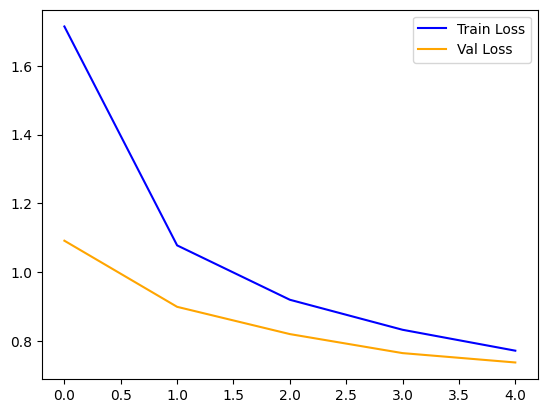

In [52]:
logs_array = np.array(logs)

plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss", c="b")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Val Loss", c="orange")

plt.legend()
plt.show()

### 11.5. Evaluate the Model

In [53]:
probs, preds, targets = eval_model(model=resnet50, dataloader=val_dataloader, device=DEVICE)

In [54]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))

              precision    recall  f1-score   support

           0       0.77      0.69      0.73       100
           1       0.75      0.75      0.75       100
           2       0.88      0.86      0.87       100
           3       0.66      0.72      0.69       100
           4       0.76      0.75      0.75       100
           5       0.73      0.63      0.68       100
           6       0.78      0.82      0.80       100
           7       0.79      0.80      0.80       100
           8       0.65      0.62      0.63       100
           9       0.86      0.91      0.88       100
          10       0.55      0.64      0.59       100
          11       0.80      0.94      0.86       100
          12       0.85      0.82      0.84       100
          13       0.93      0.90      0.91       100
          14       0.85      0.82      0.83       100
          15       0.80      0.81      0.81       100
          16       0.83      0.90      0.87       100
          17       0.81    

## **12. Save and Load**

### 12.0. Save CNN Model

In [55]:
cnn_model_dict = {
    "model_state_dict": resnet50.to("cpu").state_dict(), # Can't deserialize cuda with cpu on loading
    "num_classes": num_classes,
    "batch_size": train_dataloader.batch_size,
    "img_shape": next(iter(train_dataloader))[0][0].shape,
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "architecture": str(resnet50),
    "train_transfrom":  train_transform.transforms,
    "test_transfrom":  test_transform.transforms,
}

resnet50 = resnet50.to(DEVICE) # Put back model to current device

In [56]:
torch.save(cnn_model_dict, "pytorch_0005_resnet50.pth")

### 12.1. Load CNN Model

https://github.com/RezaTaheri01/my-ml-journey/blob/main/Codes/pytorch/models/pytorch_0005/pytorch_0005_resnet50.pth

In [123]:
# Download the pretrained model
import requests
request = requests.get("https://github.com/RezaTaheri01/my-ml-journey/raw/refs/heads/main/Codes/pytorch/models/pytorch_0005/pytorch_0005_resnet50.pth")

with open("pytorch_0005_resnet50.pth", "wb") as f:
  f.write(request.content)

In [124]:
cnn_model_dict_l = torch.load("pytorch_0005_resnet50.pth", weights_only=False)
cnn_model_dict_l.keys()

dict_keys(['model_state_dict', 'num_classes', 'batch_size', 'img_shape', 'optimizer', 'scheduler', 'architecture', 'train_transfrom', 'test_transfrom'])

In [125]:
# Load pretrained ResNet50
resnet50_temp = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze the early layers (optional for transfer learning)
for param in resnet50_temp.parameters():
    param.requires_grad = False

In [126]:
in_features = resnet50_temp.fc.in_features
resnet50_temp.fc = nn.Linear(in_features, cnn_model_dict_l["num_classes"])

In [127]:
resnet50_temp.load_state_dict(cnn_model_dict_l["model_state_dict"])

<All keys matched successfully>

In [128]:
resnet50_temp = resnet50_temp.to(DEVICE)

In [129]:
next(resnet50_temp.parameters()).device

device(type='cuda', index=0)

### 12.2. Eval Loaded Model

In [130]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)
probs, preds, targets = eval_model(model=resnet50_temp, dataloader=val_dataloader, device=DEVICE)

In [131]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.77      0.69      0.73       100
           baklava       0.75      0.75      0.75       100
          bibimbap       0.88      0.86      0.87       100
        bruschetta       0.66      0.72      0.69       100
      caesar_salad       0.76      0.75      0.75       100
        cheesecake       0.73      0.63      0.68       100
     chicken_curry       0.78      0.82      0.80       100
chicken_quesadilla       0.79      0.80      0.80       100
        crab_cakes       0.65      0.62      0.63       100
         cup_cakes       0.86      0.91      0.88       100
      filet_mignon       0.55      0.64      0.59       100
    fried_calamari       0.80      0.94      0.86       100
          pancakes       0.85      0.82      0.84       100
               pho       0.93      0.90      0.91       100
   red_velvet_cake       0.85      0.82      0.83       100
            samosa       0.80      0.81

## **13.  Making a prediction on a custom image**

### 13.0. Download and Transform Image

In [132]:
img_link = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSBTAcfwrEF4OHYxJmO4poSWv3tiKaJswBiRw&s"

In [133]:
!wget -O "waffle.jpg" {img_link}

/bin/bash: line 1: s: command not found
--2025-08-20 17:37:30--  https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSBTAcfwrEF4OHYxJmO4poSWv3tiKaJswBiRw
Resolving encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)... 142.250.153.101, 142.250.153.139, 142.250.153.113, ...
Connecting to encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)|142.250.153.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12586 (12K) [image/jpeg]
Saving to: ‘waffle.jpg’

waffle.jpg          100%[===================>]  12.29K  --.-KB/s    in 0s      

2025-08-20 17:37:30 (136 MB/s) - ‘waffle.jpg’ saved [12586/12586]



In [134]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

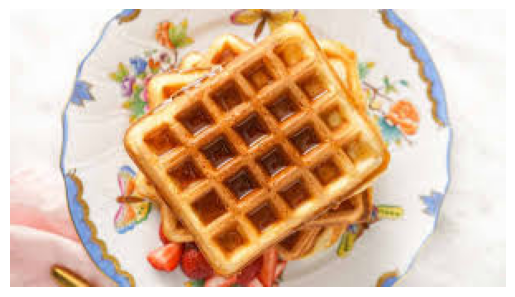

In [135]:
from PIL import Image

img = Image.open("waffle.jpg")

plt.imshow(img)
plt.axis(False)
plt.show()

In [136]:
img_transformed = transform(img)
print(f"Transformed image data type: {img_transformed.dtype} and shape: {img_transformed.shape}")

Transformed image data type: torch.float32 and shape: torch.Size([3, 224, 224])


### 13.1. Make Prediction

In [137]:
resnet50_temp.eval()
with torch.inference_mode():
  y_logit = resnet50_temp(img_transformed.unsqueeze(0).to(DEVICE))

  y_prob = torch.softmax(y_logit, dim=1)

  y_pred = torch.argmax(y_prob)

  print(f"Predicted as {class_names[y_pred]}")

Predicted as waffles


In [138]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = "cpu"):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image_raw = Image.open("waffle.jpg")

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image_raw)
    else:
        target_image = transforms.ToTensor(target_image_raw)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    # plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    plt.imshow(target_image_raw)
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

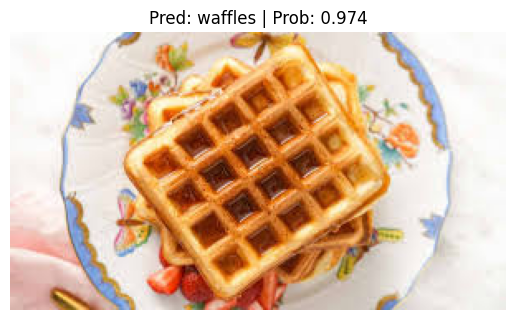

In [139]:
pred_and_plot_image(resnet50_temp,
                    "waffle.jpg",
                    class_names,
                    transform,
                    DEVICE)